# Declaration of Originality

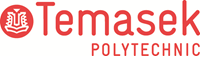

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Ho Seng Kiat Victor (2400293C)
* Tutorial Group                : PC05 
* Tutor						    : Kian Eng Ong 
* Submission Date               : 


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import numpy as np
import plotly 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'ResaleFlatPrice.csv'
df = pd.read_csv(FILE_PATH)
df


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
222213,2026-01,YISHUN,4 ROOM,334B,YISHUN ST 31,04 TO 06,92.0,Model A,2015,88 years 11 months,585000.0
222214,2026-01,YISHUN,4 ROOM,336C,YISHUN ST 31,10 TO 12,92.0,Model A,2015,88 years 11 months,620888.0
222215,2026-01,YISHUN,4 ROOM,479B,YISHUN ST 42,01 TO 03,93.0,Model A,2021,94 years 04 months,575000.0
222216,2026-01,YISHUN,4 ROOM,754,YISHUN ST 72,10 TO 12,84.0,Simplified,1985,58 years 09 months,490000.0


## 2.2 Summary Statistics

In [19]:
## Understand the type of variable for each column
df.dtypes

month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
dtype: object

In [5]:
## Check for missing data
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [6]:
## Unique values in each column
df.nunique()

month                   109
town                     26
flat_type                 7
block                  2745
street_name             577
storey_range             17
floor_area_sqm          187
flat_model               21
lease_commence_date      57
remaining_lease         694
resale_price           4553
dtype: int64

In [7]:
## Summary statistics for numerical columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,222218.000000,222218.000000,2.222180e+05
mean,96.767227,1996.436121,5.245420e+05
std,24.020346,14.302552,1.866274e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.850000e+05
50%,93.000000,1997.000000,4.920000e+05
75%,112.000000,2012.000000,6.300000e+05
max,366.700000,2022.000000,1.658888e+06


In [8]:
## Display random sample of 10 rows from the DataFrame to get a feel of the data
df.sample(10)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
45625,2019-03,JURONG EAST,4 ROOM,52,TEBAN GDNS RD,04 TO 06,83.0,Simplified,1987,67 years,290000.0
13399,2017-08,YISHUN,3 ROOM,224,YISHUN ST 21,04 TO 06,67.0,New Generation,1985,67 years,312500.0
194738,2024-10,WOODLANDS,4 ROOM,570B,WOODLANDS AVE 1,01 TO 03,92.0,Model A,2013,88 years 02 months,600000.0
216524,2025-03,TAMPINES,4 ROOM,288,TAMPINES ST 22,04 TO 06,103.0,Model A,1984,58 years 07 months,635000.0
153880,2023-01,JURONG WEST,EXECUTIVE,558,JURONG WEST ST 42,01 TO 03,148.0,Maisonette,1985,61 years 06 months,681000.0
92795,2021-03,CENTRAL AREA,4 ROOM,1A,CANTONMENT RD,37 TO 39,95.0,Type S1,2011,88 years 10 months,1028000.0
153321,2023-02,JURONG EAST,3 ROOM,412,PANDAN GDNS,04 TO 06,73.0,Improved,1979,55 years 03 months,305000.0
54638,2019-08,ANG MO KIO,5 ROOM,553,ANG MO KIO AVE 10,01 TO 03,119.0,Improved,1980,60 years,500000.0
159944,2023-06,SEMBAWANG,3 ROOM,128B,CANBERRA ST,04 TO 06,68.0,Model A,2018,94 years 05 months,455000.0
42486,2019-01,CHOA CHU KANG,5 ROOM,685A,CHOA CHU KANG CRES,10 TO 12,110.0,Improved,2002,82 years 08 months,338800.0


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

In [9]:
## Understanding distribution of target


### 2.3.1.2 Understanding distribution of features

In [10]:
## Understanding distribution of features


### 2.3.2 Understanding relationship between variables

In [11]:
## Understanding relationship between variables


# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
## Clean data

## 3.2 Train-Test Split

In [13]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [14]:
## Initialise and train model


# 5. Model Evaluation

In [15]:
## Evaluate model


In [16]:
## New data

## Predict


## Iterative model development


In [17]:
## Further feature engineering / feature selection